In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ĐỌC DỮ LIỆU

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- CẤU HÌNH ĐƯỜNG DẪN ---
# Hãy làm bước "Copy Path" như tôi hướng dẫn lúc nãy với file 'final_wide_dataset_23beacons.csv'
# Dán vào đây:
FILE_PATH = "/content/drive/MyDrive/final_wide_dataset_23beacons.csv"

# Load dữ liệu
print("⏳ Đang đọc dữ liệu...")
df = pd.read_csv(FILE_PATH)
print(f"✅ Đã load xong! Kích thước dữ liệu: {df.shape}")

# Xem thử 5 dòng đầu
display(df.head())

⏳ Đang đọc dữ liệu...
✅ Đã load xong! Kích thước dữ liệu: (1075796, 25)


,timestamp,rssi_1,rssi_2,rssi_3,rssi_4,rssi_5,rssi_6,rssi_7,rssi_8,rssi_9,...,rssi_15,rssi_16,rssi_17,rssi_18,rssi_19,rssi_20,rssi_21,rssi_22,rssi_23,location
0,2023-04-10 14:21:46.003,-110.0,-110.0,-110.0,-90.0,-110.0,-110.0,-110.0,-110.0,-110.0,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,kitchen
1,2023-04-10 14:21:46.008,-110.0,-110.0,-110.0,-90.0,-110.0,-110.0,-110.0,-110.0,-110.0,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,kitchen
2,2023-04-10 14:21:46.012,-110.0,-110.0,-110.0,-90.0,-110.0,-110.0,-110.0,-110.0,-110.0,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,kitchen
3,2023-04-10 14:21:46.018,-110.0,-110.0,-110.0,-90.0,-110.0,-110.0,-110.0,-110.0,-110.0,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,kitchen
4,2023-04-10 14:21:46.024,-110.0,-110.0,-110.0,-90.0,-110.0,-110.0,-110.0,-110.0,-110.0,...,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,-110.0,kitchen


DETERMINE MINORITY CLASS


/tmp/ipython-input-3459290798.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['timestamp'] = pd.to_datetime(df['timestamp'])


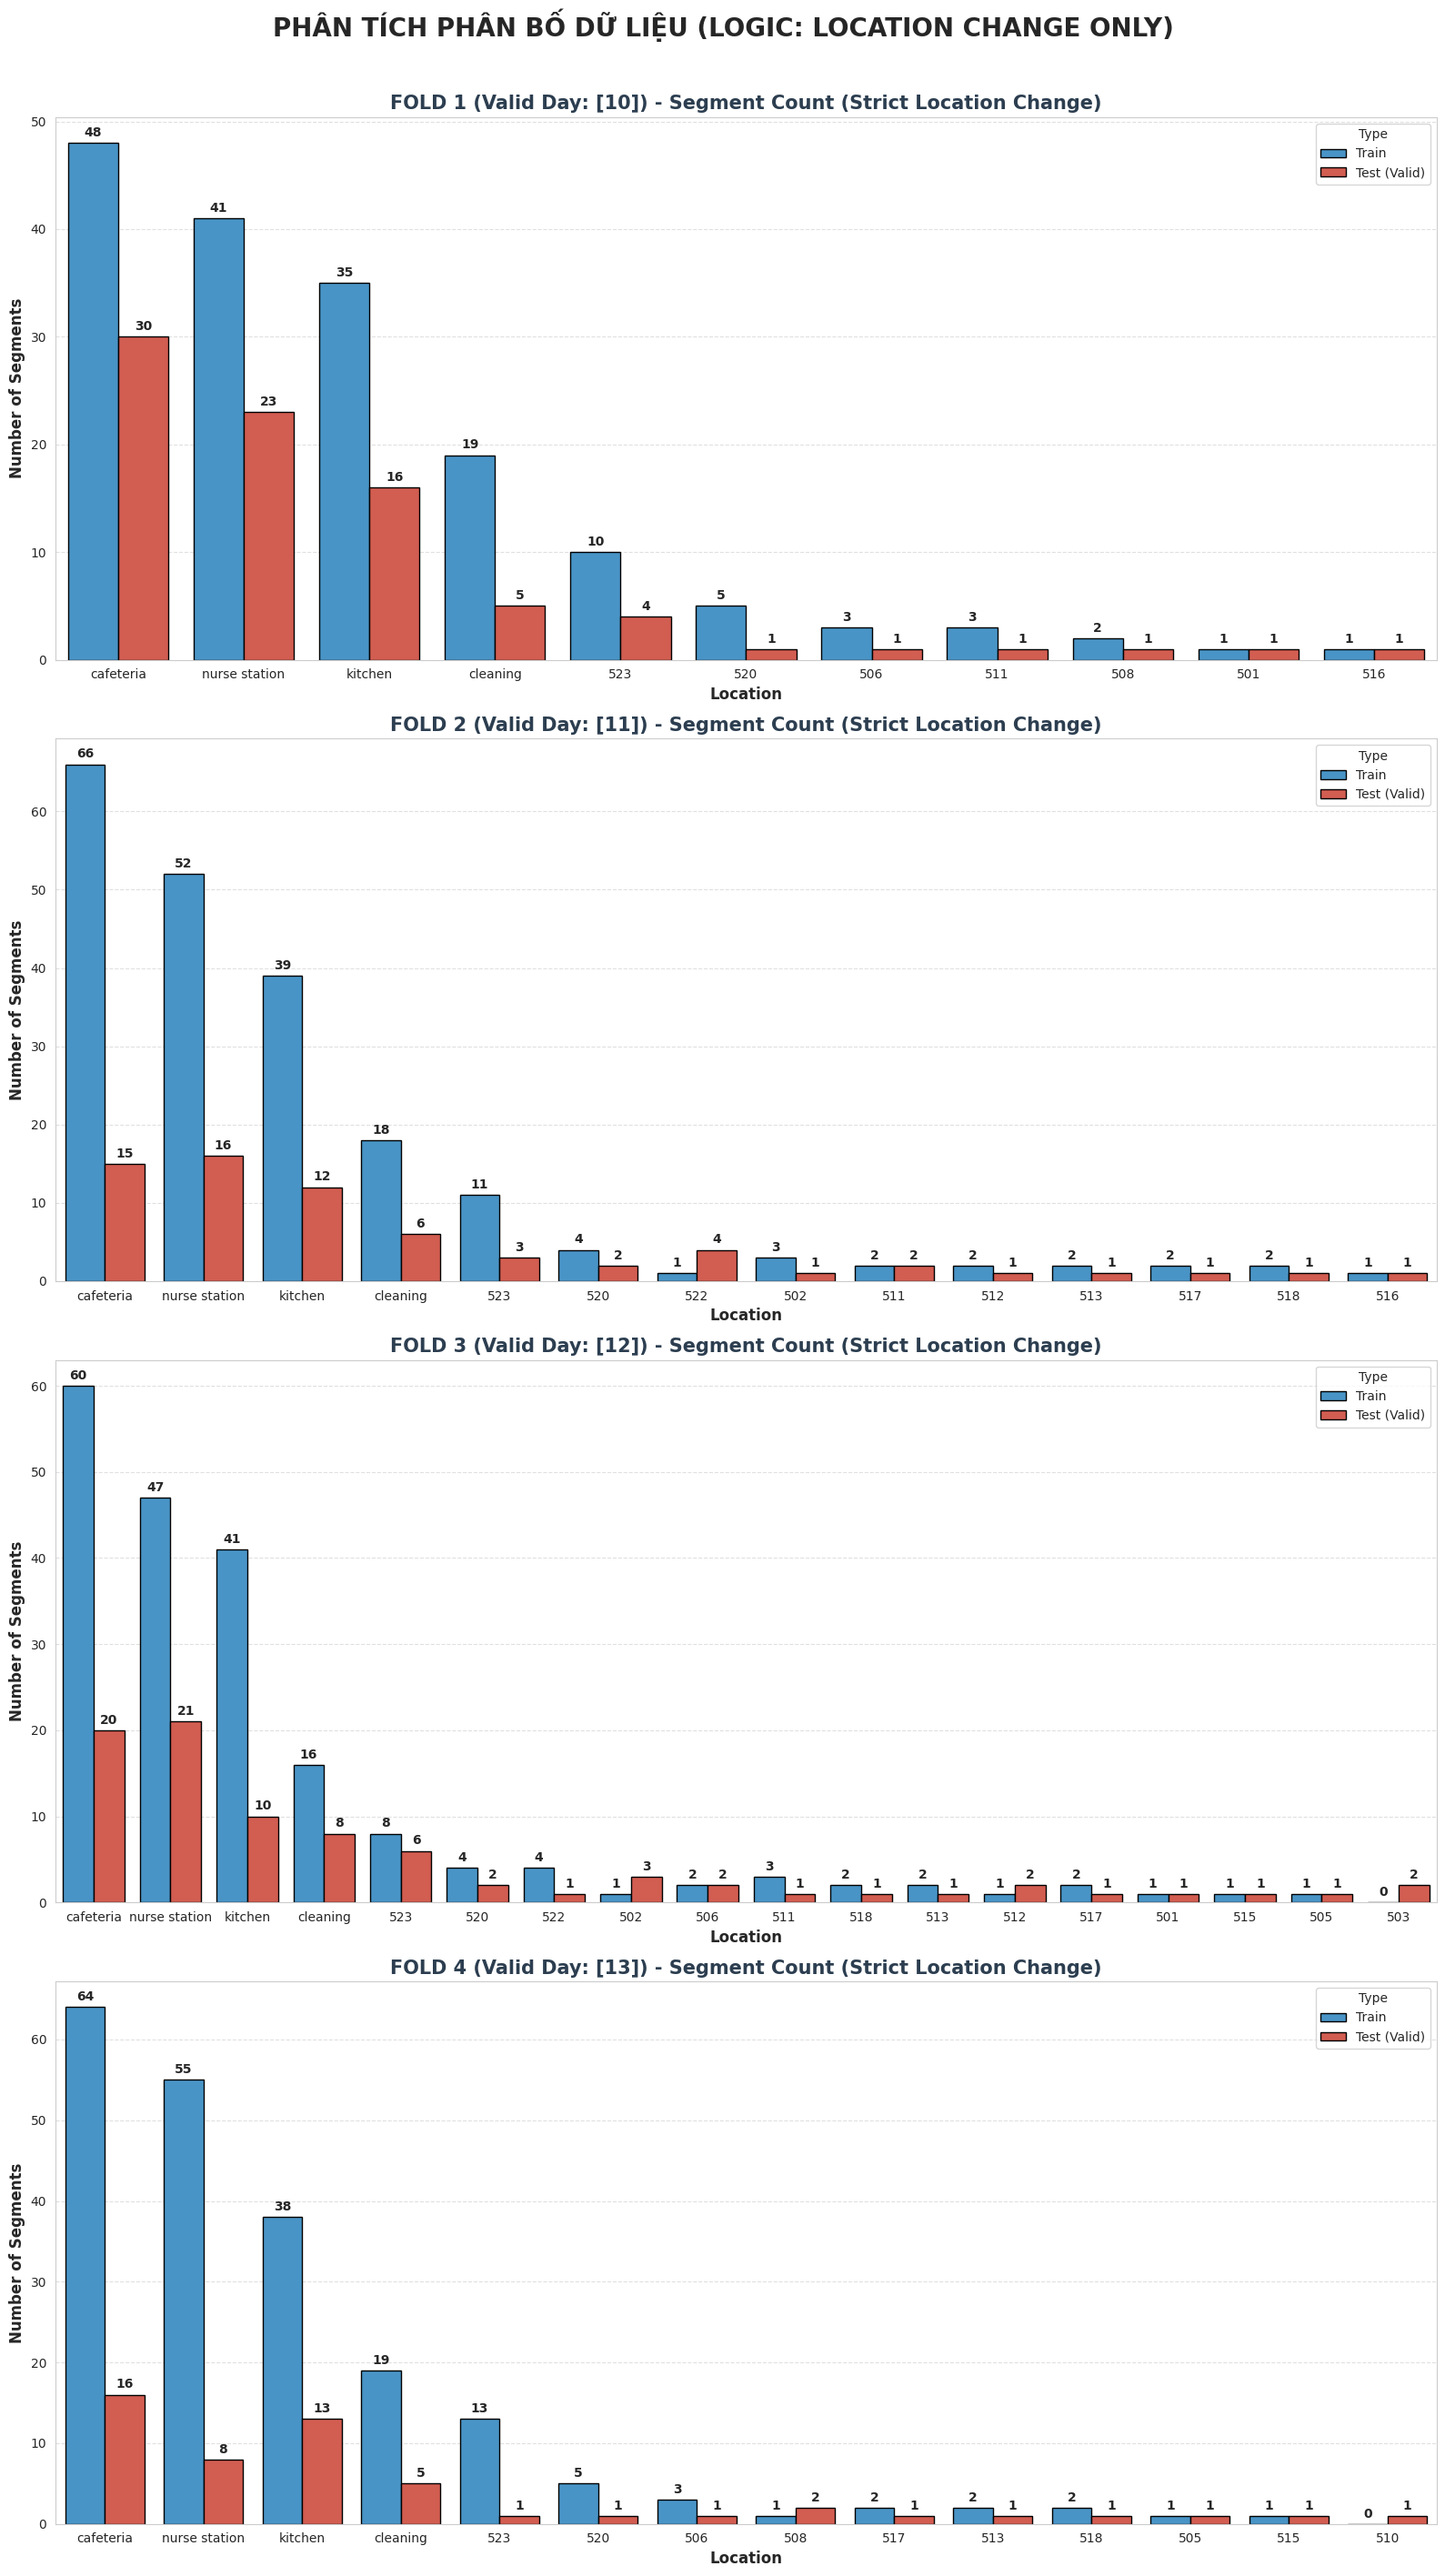

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# --- 1. CONFIGURATION ---
if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])

# Lọc bỏ Hallway
plot_df = df.copy()
if 'location' in plot_df.columns:
    plot_df = plot_df[plot_df['location'].astype(str).str.lower() != 'hallway']

fold_configs = {
    1: {'test': [10], 'train': [11, 12, 13]},
    2: {'test': [11], 'train': [10, 12, 13]},
    3: {'test': [12], 'train': [10, 11, 13]},
    4: {'test': [13], 'train': [10, 11, 12]}
}

# --- 2. HÀM ĐẾM SEGMENTS (STRICT LOGIC THEO YÊU CẦU) ---
def count_segments_strict(sub_df, label_type):
    """
    Logic: Đếm số lượng phân đoạn dựa trên sự thay đổi vị trí.
    Segment mới chỉ được tạo khi Location thay đổi (bỏ qua time gap).
    """
    if sub_df.empty:
        return pd.DataFrame(columns=['Room', 'Count', 'Type'])

    # 1. Sắp xếp theo thời gian (Rất quan trọng)
    sub_df = sub_df.copy().sort_values('timestamp')

    # 2. Tạo logic nhóm (Segmentation) - Y CHANG CODE BẠN GỬI
    # Chỉ tạo segment mới khi location dòng này khác dòng trước
    sub_df['segment_id'] = (sub_df['location'] != sub_df['location'].shift()).cumsum()

    # 3. Đếm số lượng segment unique cho mỗi phòng
    # Group by Location trước, sau đó đếm có bao nhiêu segment_id duy nhất
    counts = sub_df.groupby('location')['segment_id'].nunique().reset_index()

    counts.columns = ['Room', 'Count']
    counts['Type'] = label_type
    return counts

# --- 3. VÒNG LẶP XỬ LÝ VÀ VẼ BIỂU ĐỒ ---
fig, axes = plt.subplots(4, 1, figsize=(16, 28))
axes = axes.flatten()

for idx, (fold_id, config) in enumerate(fold_configs.items()):
    ax = axes[idx]
    test_days, train_days = config['test'], config['train']

    # Lấy dữ liệu Test để xác định Target Labels
    df_test_raw = plot_df[plot_df['timestamp'].dt.day.isin(test_days)]
    target_labels = df_test_raw['location'].unique()

    if len(target_labels) == 0:
        ax.text(0.5, 0.5, f'Không có dữ liệu Test cho Fold {fold_id}', ha='center')
        continue

    # --- ĐẾM SEGMENTS VỚI LOGIC MỚI ---
    # 1. Test Data
    counts_test = count_segments_strict(df_test_raw, 'Test (Valid)')

    # 2. Train Data (Chỉ lọc những phòng có trong Target Labels)
    df_train_raw = plot_df[plot_df['timestamp'].dt.day.isin(train_days)]
    df_train_filtered = df_train_raw[df_train_raw['location'].isin(target_labels)]
    counts_train = count_segments_strict(df_train_filtered, 'Train')

    # --- XỬ LÝ ZERO-SHOT (QUAN TRỌNG) ---
    existing_train_rooms = counts_train['Room'].unique()
    for r in target_labels:
        if r not in existing_train_rooms:
            # Thêm dòng Count=0 để biểu đồ hiện cột trống
            new_row = pd.DataFrame({'Room': [r], 'Count': [0], 'Type': ['Train']})
            counts_train = pd.concat([counts_train, new_row], ignore_index=True)

    # --- SẮP XẾP GIẢM DẦN (STYLE CŨ) ---
    # Tính tổng (Train + Test) để sắp xếp từ cao xuống thấp
    total_counts = pd.concat([counts_train, counts_test]).groupby('Room')['Count'].sum().sort_values(ascending=False)
    order_list = total_counts.index.tolist()

    plot_data = pd.concat([counts_train, counts_test], ignore_index=True)

    # --- VẼ BIỂU ĐỒ ---
    sns.barplot(
        data=plot_data,
        x='Room',
        y='Count',
        hue='Type',
        ax=ax,
        palette={'Train': '#3498db', 'Test (Valid)': '#e74c3c'},
        edgecolor='black',
        order=order_list # <--- Sắp xếp ở đây
    )

    # Định dạng "Style cũ"
    ax.yaxis.grid(True, linestyle='--', alpha=0.6) # Lưới ngang mờ
    ax.set_axisbelow(True) # Đẩy lưới xuống dưới cột
    ax.set_title(f'FOLD {fold_id} (Valid Day: {test_days}) - Segment Count (Strict Location Change)',
                 fontsize=15, fontweight='bold', color='#2c3e50')
    ax.set_xlabel('Location', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Segments', fontsize=12, fontweight='bold')

    # Hiển thị số liệu trên cột
    for container in ax.containers:
        ax.bar_label(container, padding=3, fontsize=10, fontweight='bold')

plt.suptitle('PHÂN TÍCH PHÂN BỐ DỮ LIỆU (LOGIC: LOCATION CHANGE ONLY)',
             fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

FIND SEEDS PER FOLD

In [ ]:
import pandas as pd
import numpy as np

# --- 1. HÀM TRÍCH XUẤT SEGMENT (ROBUST VERSION) ---
def get_raw_segments(df_fold, target_room_id):
    """
    Trả về TOÀN BỘ segments (Robust: So sánh cả số và chuỗi).
    """
    if df_fold.empty:
        return pd.DataFrame()

    df_fold = df_fold.sort_values('timestamp').copy()

    # Tạo logic segment (ngắt khi đổi location)
    df_fold['segment_id'] = (df_fold['location'] != df_fold['location'].shift()).cumsum()

    # --- LOGIC LỌC MẠNH MẼ (FIX LỖI WARNING MISSING) ---
    # Thử tìm chính xác trước
    mask = df_fold['location'] == target_room_id

    # Nếu không thấy, thử chuyển cả 2 về string để so sánh (Ví dụ: 501 so với '501')
    if not mask.any():
        mask = df_fold['location'].astype(str) == str(target_room_id)

    sub_df = df_fold[mask].copy()

    if sub_df.empty:
        return pd.DataFrame() # Trả về rỗng nếu vẫn không tìm thấy

    # Gom nhóm tính Duration
    stats = sub_df.groupby('segment_id').agg(
        start_time=('timestamp', 'min'),
        end_time=('timestamp', 'max')
    ).reset_index()

    stats['duration'] = (stats['end_time'] - stats['start_time']).dt.total_seconds()
    # Lưu lại location chuẩn theo target_room_id để thống nhất output
    stats['location'] = target_room_id

    return stats

# --- 2. CẤU HÌNH ---
TAU = 4

fold_configs = {
    1: {'test': [10], 'train': [11, 12, 13]},
    2: {'test': [11], 'train': [10, 12, 13]},
    3: {'test': [12], 'train': [10, 11, 13]},
    4: {'test': [13], 'train': [10, 11, 12]}
}

proxy_map = {
    (3, 503): 516,
    (4, 510): 511
}

final_results = []

print(f"🚀 BẮT ĐẦU QUÉT (Logic: Count Raw < {TAU} -> Then Filter > 2s)...")
print("-" * 60)

# --- 3. VÒNG LẶP CHÍNH ---
for fold_id, config in fold_configs.items():
    print(f"Checking Fold {fold_id}...")

    train_days = config['train']
    test_days = config['test']

    df_train_fold = df[df['timestamp'].dt.day.isin(train_days)]
    df_test_fold = df[df['timestamp'].dt.day.isin(test_days)]

    target_rooms = df_test_fold['location'].unique()

    for room in target_rooms:
        # Xử lý ID phòng an toàn (để tra cứu map)
        try:
            room_id = int(room)
        except ValueError:
            room_id = room # Giữ nguyên nếu là 'kitchen'

        if str(room_id).lower() == 'hallway':
            continue

        # BƯỚC 1: Lấy segments thô
        raw_segs = get_raw_segments(df_train_fold, room_id)
        raw_count = len(raw_segs)

        # BƯỚC 2: Quyết định
        if raw_count >= TAU:
            pass

        elif 0 < raw_count < TAU:
            print(f"  [Minority] Room {room_id}: Raw count {raw_count} < {TAU}. Selecting...")
            # Lọc sạch > 2s
            clean_segs = raw_segs[raw_segs['duration'] > 2.0]

            if not clean_segs.empty:
                for _, row in clean_segs.iterrows():
                    final_results.append((
                        fold_id, room_id,
                        f"'{row['start_time']}'", f"'{row['end_time']}'",
                        round(row['duration'], 3)
                    ))

        elif raw_count == 0:
            # Tra cứu Proxy
            lookup_key = (fold_id, room_id)
            if lookup_key in proxy_map:
                proxy_room = proxy_map[lookup_key]
                print(f"  [Zero-Shot] Room {room_id} missing. Using PROXY {proxy_room}.")

                # Lấy data Proxy
                proxy_raw = get_raw_segments(df_train_fold, proxy_room)

                # --- FIX KEYERROR TẠI ĐÂY ---
                if proxy_raw.empty:
                    print(f"     -> [ERROR] Proxy Room {proxy_room} data NOT FOUND in DF!")
                else:
                    proxy_clean = proxy_raw[proxy_raw['duration'] > 2.0]

                    if not proxy_clean.empty:
                        print(f"     -> Extracted {len(proxy_clean)} clean segments from Proxy {proxy_room}.")
                        for _, row in proxy_clean.iterrows():
                            final_results.append((
                                fold_id, proxy_room,
                                f"'{row['start_time']}'", f"'{row['end_time']}'",
                                round(row['duration'], 3)
                            ))
                    else:
                        print(f"     -> Proxy {proxy_room} found but all segments < 2s.")
            else:
                if str(room_id).lower() != 'hallway':
                    print(f"  [Warning] Room {room_id} missing & no Proxy!")

# --- 4. IN KẾT QUẢ ---
print("\n" + "="*30)
print("segments_config = [")
curr_fold = 0
for item in final_results:
    if item[0] != curr_fold:
        print(f"\n    # --- FOLD {item[0]} ---")
        curr_fold = item[0]
    print(f"    {item},")
print("]")

🚀 BẮT ĐẦU QUÉT (Logic: Count Raw < 4 -> Then Filter > 2s)...
------------------------------------------------------------
Checking Fold 1...
  [Minority] Room 501: Raw count 1 < 4. Selecting...
  [Minority] Room 506: Raw count 3 < 4. Selecting...
  [Minority] Room 511: Raw count 3 < 4. Selecting...
  [Minority] Room 516: Raw count 1 < 4. Selecting...
  [Minority] Room 508: Raw count 2 < 4. Selecting...
Checking Fold 2...
  [Minority] Room 511: Raw count 2 < 4. Selecting...
  [Minority] Room 512: Raw count 2 < 4. Selecting...
  [Minority] Room 522: Raw count 1 < 4. Selecting...
  [Minority] Room 502: Raw count 3 < 4. Selecting...
  [Minority] Room 516: Raw count 1 < 4. Selecting...
  [Minority] Room 518: Raw count 2 < 4. Selecting...
  [Minority] Room 513: Raw count 2 < 4. Selecting...
  [Minority] Room 517: Raw count 2 < 4. Selecting...
Checking Fold 3...
  [Minority] Room 502: Raw count 1 < 4. Selecting...
  [Minority] Room 512: Raw count 1 < 4. Selecting...
  [Minority] Room 513: Raw

CREATE FAKE DATA

🚀 Bắt đầu sinh dữ liệu (6 mẫu/config)...

[Fold 1] Config 0: Room 511 (Duration: 123.855s)
   ✅ Generated 6 fake samples (Label: 511).
   📊 Drawing comparison...


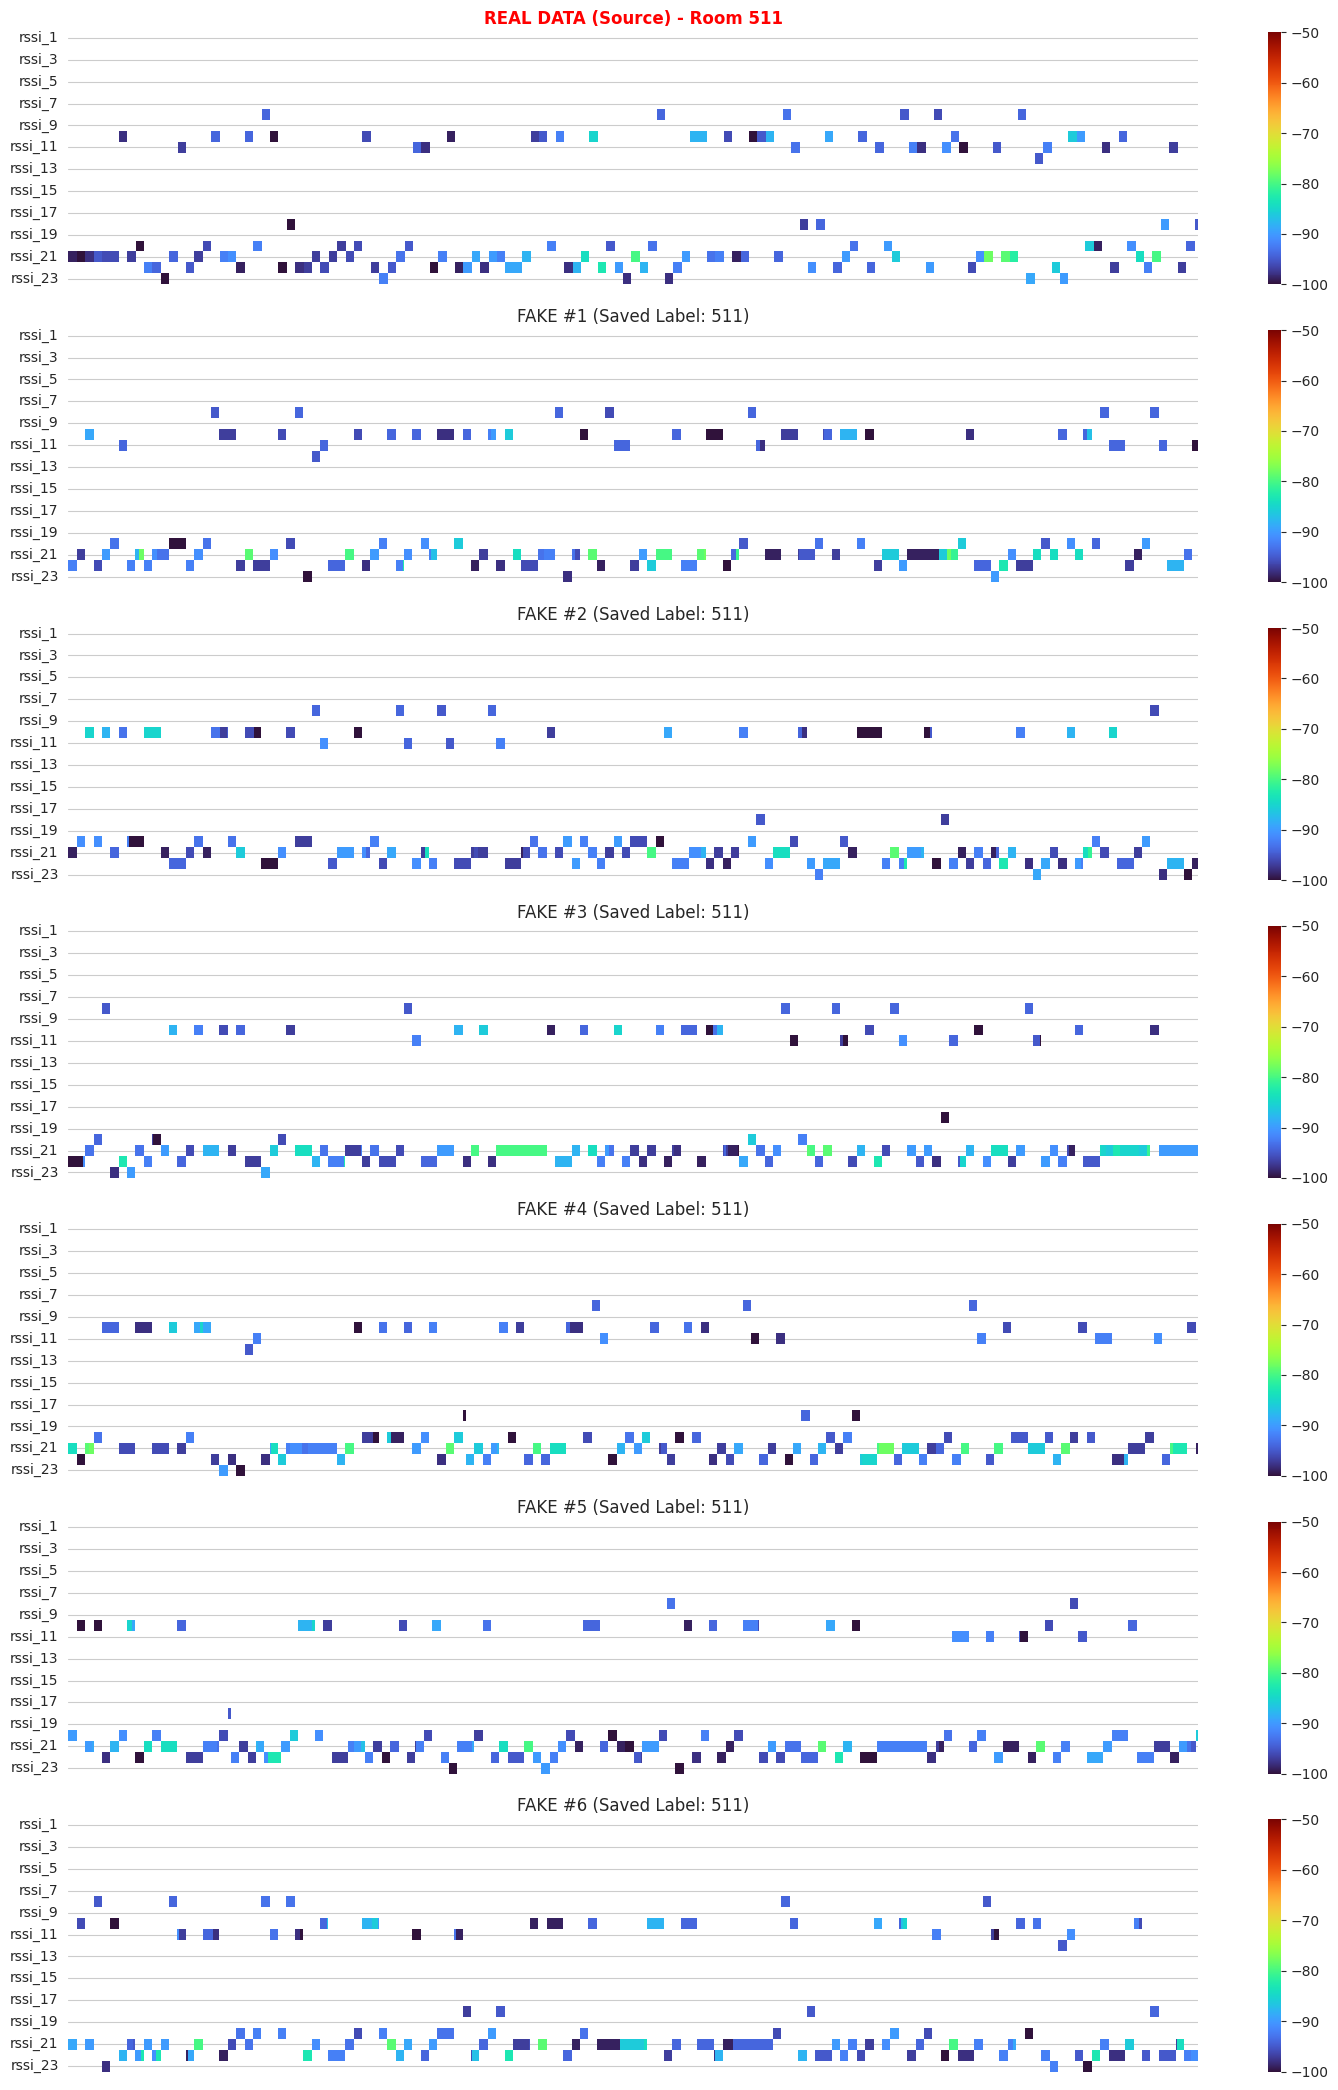


[Fold 1] Config 1: Room 511 (Duration: 32.352s)
   ✅ Generated 6 fake samples (Label: 511).
   📊 Drawing comparison...


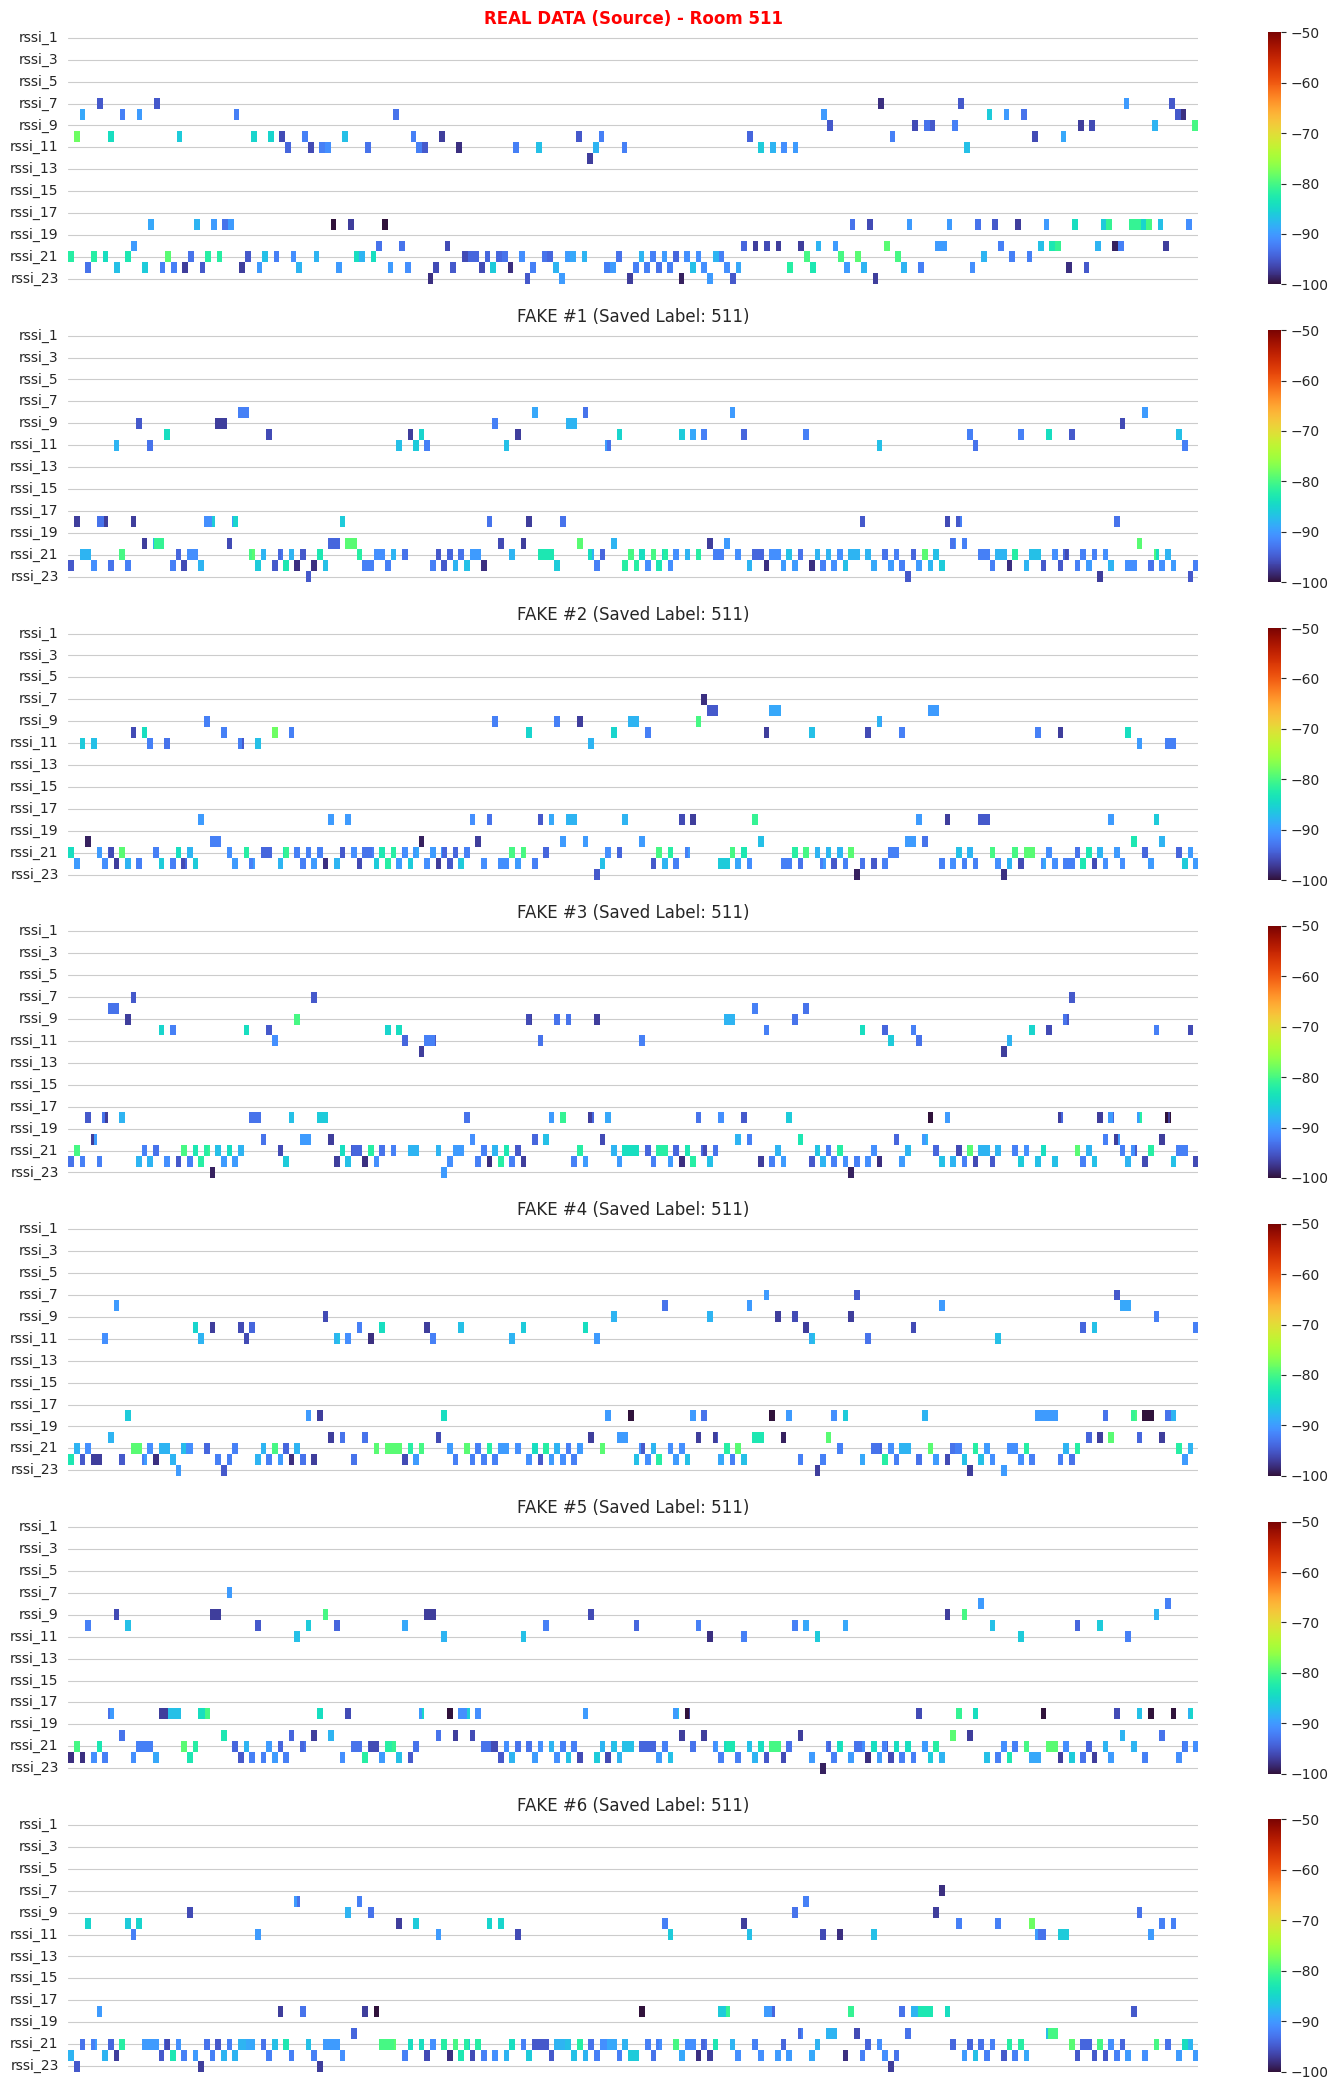


[Fold 1] Config 2: Room 511 (Duration: 213.009s)
   ✅ Generated 6 fake samples (Label: 511).

[Fold 1] Config 3: Room 506 (Duration: 129.701s)
   ✅ Generated 6 fake samples (Label: 506).

[Fold 1] Config 4: Room 506 (Duration: 16.553s)
   ✅ Generated 6 fake samples (Label: 506).

[Fold 1] Config 5: Room 506 (Duration: 173.212s)
   ✅ Generated 6 fake samples (Label: 506).

[Fold 1] Config 6: Room 508 (Duration: 20.106s)
   ✅ Generated 6 fake samples (Label: 508).

[Fold 1] Config 7: Room 508 (Duration: 5.595s)
   ✅ Generated 6 fake samples (Label: 508).

[Fold 1] Config 8: Room 516 (Duration: 11.883s)
   ✅ Generated 6 fake samples (Label: 516).

[Fold 1] Config 9: Room 501 (Duration: 79.14s)
   ✅ Generated 6 fake samples (Label: 501).

[Fold 2] Config 10: Room 502 (Duration: 59.982s)
   ✅ Generated 6 fake samples (Label: 502).

[Fold 2] Config 11: Room 502 (Duration: 21.162s)
   ✅ Generated 6 fake samples (Label: 502).

[Fold 2] Config 12: Room 502 (Duration: 127.619s)
   ✅ Generated 6

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# --- 1. CONFIGURATION ---
NUM_FAKES_PER_CONFIG =  6 # Sinh 5 mẫu giả cho mỗi cấu hình
OUTPUT_CSV_PATH = '/content/drive/MyDrive/fakedata_labeled_yes_2_2.csv'

# DANH SÁCH CẤU HÌNH (ĐÃ THÊM ID FOLD VÀO ĐẦU)
# Format: (Fold ID, Room ID, Start Time, End Time, Duration Sec)
segments_config = [
    # --- FOLD 1 ---
    (1, 511, '2023-04-11 14:16:45.143000', '2023-04-11 14:18:48.998000', 123.855),
    (1, 511, '2023-04-11 14:38:31.130000', '2023-04-11 14:39:03.482000', 32.352),
    (1, 511, '2023-04-12 11:23:12.941000', '2023-04-12 11:26:45.950000', 213.009),
    (1, 506, '2023-04-12 15:15:23.299000', '2023-04-12 15:17:33', 129.701),
    (1, 506, '2023-04-12 15:50:41.009000', '2023-04-12 15:50:57.562000', 16.553),
    (1, 506, '2023-04-13 10:22:20.777000', '2023-04-13 10:25:13.989000', 173.212),
    (1, 508, '2023-04-13 10:19:18.003000', '2023-04-13 10:19:38.109000', 20.106),
    (1, 508, '2023-04-13 10:52:30.922000', '2023-04-13 10:52:36.517000', 5.595),
    (1, 516, '2023-04-11 14:56:37.116000', '2023-04-11 14:56:48.999000', 11.883),
    (1, 501, '2023-04-12 11:13:54.859000', '2023-04-12 11:15:13.999000', 79.140),

    # --- FOLD 2 ---
    (2, 502, '2023-04-12 10:07:44.018000', '2023-04-12 10:08:44', 59.982),
    (2, 502, '2023-04-12 15:14:53.399000', '2023-04-12 15:15:14.561000', 21.162),
    (2, 502, '2023-04-12 15:24:25.716000', '2023-04-12 15:26:33.335000', 127.619),
    (2, 511, '2023-04-10 14:42:49.001000', '2023-04-10 14:43:44.258000', 55.257),
    (2, 511, '2023-04-12 11:23:12.941000', '2023-04-12 11:26:45.950000', 213.009),
    (2, 512, '2023-04-12 10:24:01.829000', '2023-04-12 10:25:00', 58.171),
    (2, 512, '2023-04-12 11:36:14.065000', '2023-04-12 11:43:44.281000', 450.216),
    (2, 513, '2023-04-12 10:55:57.704000', '2023-04-12 11:04:05.843000', 488.139),
    (2, 513, '2023-04-13 11:01:43', '2023-04-13 11:08:04.124000', 381.124),
    (2, 517, '2023-04-13 11:19:35.540000', '2023-04-13 11:20:44.468000', 68.928),
    (2, 518, '2023-04-12 16:23:42.239000', '2023-04-12 16:23:54.584000', 12.345),
    (2, 518, '2023-04-13 11:22:09.336000', '2023-04-13 11:23:35.028000', 85.692),
    (2, 516, '2023-04-10 16:05:30', '2023-04-10 16:05:46.997000', 16.997),
    (2, 522, '2023-04-12 11:28:41.020000', '2023-04-12 11:33:11.998000', 270.978),

    # --- FOLD 3 ---
    (3, 511, '2023-04-10 14:42:49.001000', '2023-04-10 14:43:44.258000', 55.257),
    (3, 511, '2023-04-11 14:16:45.143000', '2023-04-11 14:18:48.998000', 123.855),
    (3, 511, '2023-04-11 14:38:31.130000', '2023-04-11 14:39:03.482000', 32.352),
    (3, 506, '2023-04-10 14:28:09.012000', '2023-04-10 14:29:27.997000', 78.985),
    (3, 506, '2023-04-13 10:22:20.777000', '2023-04-13 10:25:13.989000', 173.212),
    (3, 517, '2023-04-11 16:52:32.530000', '2023-04-11 16:52:48.995000', 16.465),
    (3, 517, '2023-04-13 11:19:35.540000', '2023-04-13 11:20:44.468000', 68.928),
    (3, 518, '2023-04-11 14:57:10.169000', '2023-04-11 14:57:13.929000', 3.760),
    (3, 518, '2023-04-13 11:22:09.336000', '2023-04-13 11:23:35.028000', 85.692),
    (3, 513, '2023-04-11 14:59:56.926000', '2023-04-11 15:00:11.999000', 15.073),
    (3, 513, '2023-04-13 11:01:43', '2023-04-13 11:08:04.124000', 381.124),
    (3, 501, '2023-04-10 14:24:31.006000', '2023-04-10 14:26:37.887000', 126.881),
    (3, 502, '2023-04-11 14:56:20.070000', '2023-04-11 14:56:27.998000', 7.928),
    (3, 512, '2023-04-11 14:20:31.444000', '2023-04-11 14:26:44.872000', 373.428),
    (3, 515, '2023-04-13 10:10:16.851000', '2023-04-13 10:14:57.468000', 280.617),
    (3, 505, '2023-04-13 11:01:14.137000', '2023-04-13 11:01:41.997000', 27.860),
    (3, 516, "'2023-04-10 16:05:30'", "'2023-04-10 16:05:34'", 4.0),
    (3, 516, "'2023-04-11 14:56:37'", "'2023-04-11 14:56:48'", 11.0),

    # --- FOLD 4 ---
    (4, 506, '2023-04-10 14:28:09.012000', '2023-04-10 14:29:27.997000', 78.985),
    (4, 506, '2023-04-12 15:15:23.299000', '2023-04-12 15:17:33', 129.701),
    (4, 506, '2023-04-12 15:50:41.009000', '2023-04-12 15:50:57.562000', 16.553),
    (4, 518, '2023-04-11 14:57:10.169000', '2023-04-11 14:57:13.929000', 3.760),
    (4, 518, '2023-04-12 16:23:42.239000', '2023-04-12 16:23:54.584000', 12.345),
    (4, 513, '2023-04-11 14:59:56.926000', '2023-04-11 15:00:11.999000', 15.073),
    (4, 513, '2023-04-12 10:55:57.704000', '2023-04-12 11:04:05.843000', 488.139),
    (4, 517, '2023-04-11 16:52:32.530000', '2023-04-11 16:52:48.995000', 16.465),
    (4, 511, "'2023-04-10 14:43:16'", "'2023-04-10 14:43:44'", 28.0),
    (4, 511, "'2023-04-12 11:25:53'", "'2023-04-12 11:26:45'", 52.0),
    (4, 511, "'2023-04-11 14:18:26'", "'2023-04-11 14:18:48'", 22.0),
    (4, 511, "'2023-04-11 14:38:50'", "'2023-04-11 14:39:03'", 13.0),
    (4, 511, "'2023-04-10 14:42:49'", "'2023-04-10 14:42:58'", 9.0),
    (4, 508, '2023-04-10 16:11:37.368000', '2023-04-10 16:14:12.956000', 155.588),
    (4, 515, '2023-04-12 11:05:08.004000', '2023-04-12 11:10:05.992000', 297.988),
    (4, 505, '2023-04-12 15:02:30.003000', '2023-04-12 15:02:32.188000', 2.185)

]

# --- 2. HÀM CỐT LÕI (RUN SIMULATION) ---
def run_simulation(full_df, start_str, end_str, target_duration, room_id, run_idx):
    SHARPEN_FACTOR = 2

    # 2.1 Load & Filter Data
    if 'timestamp' in full_df.columns:
        full_df['timestamp'] = pd.to_datetime(full_df['timestamp'])
        full_df = full_df.set_index('timestamp').sort_index()

    real_df = full_df[(full_df.index >= start_str) & (full_df.index <= end_str)].copy()
    rssi_cols = [c for c in real_df.columns if 'rssi' in c]

    if len(real_df) < 2: return None, None

    # Auto Step
    time_diffs = real_df.index.to_series().diff().dropna()
    step_ms = int(max(4, time_diffs.mean().total_seconds() * 1000))

    # Active Beacon
    def get_active_beacon(row):
        valid = row[row > -109]
        if valid.empty: return None
        return valid.idxmax()

    real_df['active_beacon'] = real_df[rssi_cols].apply(get_active_beacon, axis=1)
    real_df = real_df.dropna(subset=['active_beacon'])
    if real_df.empty: return None, None

    # Block Creation
    real_df['block_id'] = (real_df['active_beacon'] != real_df['active_beacon'].shift()).cumsum()
    blocks = []
    for bid, group in real_df.groupby('block_id'):
        beacon = group['active_beacon'].iloc[0]
        n_rows = len(group)
        values = group[beacon].values
        deltas = np.diff(values)
        blocks.append({
            'beacon': beacon, 'num_rows': n_rows, 'values': values, 'deltas': deltas, 'start_val': values[0]
        })

    # Learn Stats
    stats = {}
    transition_counts = {b: {} for b in rssi_cols}
    all_block_beacons = [b['beacon'] for b in blocks]
    global_counts = Counter(all_block_beacons)
    total_blocks = sum(global_counts.values())
    sorted_beacons = sorted(global_counts.keys())
    raw_probs = np.array([global_counts[b] / total_blocks for b in sorted_beacons])
    sharp_probs = np.power(raw_probs, SHARPEN_FACTOR)
    global_probs = sharp_probs / sharp_probs.sum()

    for b_name in rssi_cols:
        b_blocks = [b for b in blocks if b['beacon'] == b_name]
        if not b_blocks: continue
        raw_counts = [b['num_rows'] for b in b_blocks]
        count_counter = Counter(raw_counts)
        unique_counts = list(count_counter.keys())
        count_probs = [count_counter[c]/len(raw_counts) for c in unique_counts]
        all_deltas = np.concatenate([b['deltas'] for b in b_blocks]) if b_blocks else []
        start_vals = [b['start_val'] for b in b_blocks]
        stats[b_name] = {
            'unique_counts': unique_counts, 'count_probs': count_probs,
            'deltas': all_deltas if len(all_deltas)>0 else [0],
            'start_vals': start_vals,
            'min_rssi': min([min(b['values']) for b in b_blocks]),
            'max_rssi': max([max(b['values']) for b in b_blocks])
        }

    for i in range(len(blocks) - 1):
        curr, next_b = blocks[i]['beacon'], blocks[i+1]['beacon']
        if next_b not in transition_counts[curr]: transition_counts[curr][next_b] = 0
        transition_counts[curr][next_b] += 1

    transition_probs = {b: {} for b in rssi_cols}
    for b, targets in transition_counts.items():
        total = sum(targets.values())
        if total > 0:
            candidates = list(targets.keys())
            raw_p = np.array([targets[c]/total for c in candidates])
            sharp_p = np.power(raw_p, SHARPEN_FACTOR)
            norm_p = sharp_p / sharp_p.sum()
            for i, cand in enumerate(candidates): transition_probs[b][cand] = norm_p[i]

    # Generate
    generated_rows = []
    current_time = pd.Timestamp(start_str)
    end_timestamp = current_time + pd.Timedelta(seconds=target_duration)
    current_beacon = np.random.choice(sorted_beacons, p=global_probs)

    while current_time < end_timestamp:
        if current_beacon not in stats:
            current_beacon = np.random.choice(sorted_beacons, p=global_probs)
            continue
        num_rows = np.random.choice(stats[current_beacon]['unique_counts'], p=stats[current_beacon]['count_probs'])
        current_rssi = np.random.choice(stats[current_beacon]['start_vals'])
        for _ in range(num_rows):
            if current_time >= end_timestamp: break
            row_data = {col: -110.0 for col in rssi_cols}
            row_data[current_beacon] = current_rssi
            row_data['timestamp'] = current_time
            generated_rows.append(row_data)
            current_time += pd.Timedelta(milliseconds=step_ms)
            delta = np.random.choice(stats[current_beacon]['deltas'])
            current_rssi += delta
            current_rssi = np.clip(current_rssi, stats[current_beacon]['min_rssi'], stats[current_beacon]['max_rssi'])

        possible_next = transition_probs.get(current_beacon, {})
        if possible_next:
            candidates = list(possible_next.keys())
            probs = list(possible_next.values())
            current_beacon = np.random.choice(candidates, p=probs)
        else:
            current_beacon = np.random.choice(sorted_beacons, p=global_probs)

    return real_df, pd.DataFrame(generated_rows).set_index('timestamp')

# --- 3. MAIN LOOP ---
print(f"🚀 Bắt đầu sinh dữ liệu (6 mẫu/config)...")
all_fake_dfs = []

for idx, cfg in enumerate(segments_config):
    fold_id, r_id, s_time, e_time, dur = cfg # Unpack thêm Fold ID

    print(f"\n[Fold {fold_id}] Config {idx}: Room {r_id} (Duration: {dur}s)")

    # Lấy Real Data (Source) để học thống kê (Vẫn dùng ID gốc để học pattern)
    try:
        real_data_sample, _ = run_simulation(df, s_time, e_time, dur, r_id, 0)
    except:
        continue

    if real_data_sample is None: continue

    # Sinh các mẫu giả
    fakes_for_this = []
    for run_i in range(NUM_FAKES_PER_CONFIG):
        try:
            _, fake_data = run_simulation(df, s_time, e_time, dur, r_id, run_i)

            if fake_data is not None and not fake_data.empty:
                # --- LOGIC ĐỔI NHÃN (LABEL SWAPPING) ---
                final_label = r_id # Mặc định là giữ nguyên nhãn gốc

                # Rule 1: Fold 3, Room 516 -> Đổi thành 503
                if fold_id == 3 and r_id == 516:
                    final_label = 503
                    if run_i == 0: print(f"   ⚠️ [Fold 3 Logic] Đã đổi nhãn 516 -> 503")

                # Rule 2: Fold 4, Room 511 -> Đổi thành 510
                elif fold_id == 4 and r_id == 511:
                    final_label = 510
                    if run_i == 0: print(f"   ⚠️ [Fold 4 Logic] Đã đổi nhãn 511 -> 510")

                # Gán nhãn đã xử lý vào data
                fake_data['location'] = final_label
                fake_data['fold'] = fold_id
                fake_data['is_augmented'] = True
                fake_data['source_config_id'] = idx

                fakes_for_this.append(fake_data)
                all_fake_dfs.append(fake_data)
        except Exception as e:
            # print(e) # Uncomment if debug needed
            pass

    print(f"   ✅ Generated {len(fakes_for_this)} fake samples (Label: {final_label if fakes_for_this else r_id}).")

    # Vẽ kiểm tra 2 config đầu tiên (Vẽ theo nhãn gốc để so sánh pattern)
    if idx < 2 and len(fakes_for_this) > 0:
        print(f"   📊 Drawing comparison...")
        rssi_cols = [c for c in real_data_sample.columns if 'rssi' in c]
        fig, axes = plt.subplots(1 + len(fakes_for_this), 1, figsize=(15, 3 * (1+len(fakes_for_this))))

        # Real
        d_real = real_data_sample[rssi_cols].reset_index(drop=True).replace(-110, np.nan).T
        sns.heatmap(d_real, ax=axes[0], cmap='turbo', vmin=-100, vmax=-50, cbar=True, xticklabels=False)
        axes[0].set_title(f"REAL DATA (Source) - Room {r_id}", fontweight='bold', color='red')

        # Fakes
        for i, fake_df in enumerate(fakes_for_this):
            d_fake = fake_df[rssi_cols].reset_index(drop=True).replace(-110, np.nan).T
            # Hiển thị tiêu đề kèm nhãn thực tế đã lưu
            lbl = fake_df['location'].iloc[0]
            sns.heatmap(d_fake, ax=axes[i+1], cmap='turbo', vmin=-100, vmax=-50, cbar=True, xticklabels=False)
            axes[i+1].set_title(f"FAKE #{i+1} (Saved Label: {lbl})")

        plt.tight_layout()
        plt.show()

# --- 4. SAVE ---
if all_fake_dfs:
    final_df = pd.concat(all_fake_dfs).reset_index()
    final_df.to_csv(OUTPUT_CSV_PATH, index=False)
    print(f"\n🎉 Đã lưu {len(final_df)} dòng vào: {OUTPUT_CSV_PATH}")
    print(f"👉 Khi train, hãy nhớ lọc: df[df['fold'] == current_fold]")
else:
    print("❌ Thất bại.")